# Assignment 3

## Objective

The goal of this assignment is to:

* implement **binary logistic regression** in PyTorch using only tensors,
* compute gradients for logistic regression **manually** (without using `.grad` for parameter updates),
* implement **gradient descent manually**,
* build and train an **MLP with 1 or 2 hidden layers**,
* understand binary classification with **sigmoid + binary cross-entropy**,
* work with an image dataset by **flattening images into vectors**.


---

## 📌 General Requirements

* Use **PyTorch**
* Submit a **Jupyter Notebook (.ipynb)**
* Notebook must:
  * run from top to bottom without errors,
  * include markdown explanations,
  * include plots where required,
  * set a random seed,
  * use clear variable names,
  * be reproducible.

You may use a dataset such as **Fashion-MNIST**
@[https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html](mention://dac22907-0ddd-428c-8ed2-30b69f15f97c/url/970c64e1-87da-4a39-9989-2cb94da80d34)


---

# ⚠ Restrictions (Important)

For the entire assignment:

✅ Allowed:

* `torch.Tensor` operations
* `torch.exp`, `torch.log`, `torch.matmul`, `@`
* indexing, masking, reshaping, flattening
* `torchvision.datasets` only for loading data
* plotting libraries such as `matplotlib`

❌ Not allowed in **Task 1**:

* `loss.backward()`
* `.grad` for computing logistic regression parameter updates
* `torch.optim.*`
* `torch.nn.Linear`
* high-level loss modules such as `nn.BCELoss`, `nn.BCEWithLogitsLoss`
* high-level training wrappers

❌ Not allowed in **all tasks**:

* `torch.optim.*`
* high-level training wrappers (Lightning, fastai, Trainer APIs)

⚠ For the MLP tasks, you may use autograd via `loss.backward()`, but you must still implement:

* the forward pass yourself,
* the parameter tensors yourself,
* the parameter updates manually.

## Imports

In [1]:
from ctypes import DEFAULT_MODE

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets, transforms
from PIL import Image
torch.manual_seed(42)

## Dataset

In [2]:
transformations = transforms.Compose([
    transforms.ToTensor(),
    nn.Flatten()
])

In [3]:
dataset = datasets.FashionMNIST(root='./dataset', download=True)

In [4]:
X = torch.flatten(dataset.data, start_dim=1)
y = (dataset.targets == 5).long()

In [5]:
Image.fromarray((X[y == 1][0]).reshape(28, 28).numpy())

In [6]:
X_pos = X[y == 1]

indices = torch.randperm(len(X_pos))
X_neg = X[y == 0][indices]

X_balanced = torch.concat((X_pos, X_neg))

In [7]:
y_pos = y[y == 1]
y_neg = y[indices]

y_balanced = torch.concat((y_pos, y_neg))

In [8]:
N = X_balanced.shape[0]
perm = torch.randperm(N)

train_size = 0.8
n_test = int(train_size * N)

train_idx = perm[:n_test]
val_idx = perm[n_test:]

X_train = X_balanced[train_idx]
X_val = X_balanced[val_idx]
y_train = y_balanced[train_idx].unsqueeze(1)
y_val = y_balanced[val_idx].unsqueeze(1)

In [9]:
print(X_train.shape)
print(X_val.shape)

torch.Size([9600, 784])
torch.Size([2400, 784])


Report:
* which class you chose as positive - heel (5)
* the number of positive and negative sample - 6000, 6000
* the shapes of the resulting tensors - [9600, 784], [2400, 784]

# Task 1 — Logistic Regression with Manual Gradient Calculation (3 pts)

We consider the logistic regression model

$$
z = XW + b
$$

$$
\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}
$$

where

* $$
  X \in \mathbb{R}^{N \times d}
  $$
* $$
  W \in \mathbb{R}^{d \times 1}
  $$
* $$
  b \in \mathbb{R}
  $$
* $$
  \hat{y} \in \mathbb{R}^{N \times 1}
  $$

Use flattened image vectors, so typically $d = 784$.

## Requirements


1. Prepare the balanced binary dataset described above.
2. Flatten images into vectors.
3. Create two input versions:
   * **raw-like scale**: values in $[0,255]$
   * **normalized scale**: values in $[0,1]$
4. Initialize parameters: $W$, $b$ randomly
5. Implement the forward pass manually:
   * linear logits $z$,
   * sigmoid predictions $\hat{y}$.
6. Implement the **binary cross-entropy loss manually**:

$$
L = -\frac{1}{N} \sum_{i=1}^N \left[
y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)
\right]
$$


7. Compute the gradients **manually**, using formulas derived in class:

$$
\frac{\partial L}{\partial z} = \hat{y} - y
$$

$$
\frac{\partial L}{\partial W} = \frac{1}{N} X^T (\hat{y} - y)
$$

$$
\frac{\partial L}{\partial b} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)
$$


 8. Implement manual gradient descent updates:
    * update $W$ and $b$ yourself,
    * do **not** use `.backward()` or `.grad`.
 9. Train for at least **100 epochs**.
10. Track:
    * training loss,
    * validation loss,
    * training accuracy,
    * validation accuracy.

## Plots

Plot:

* training loss vs epoch,
* validation loss vs epoch,
* training accuracy vs epoch,
* validation accuracy vs epoch.


In [22]:
X_train_norm = X_train / 255
X_val_norm = X_val / 255

In [23]:
W = torch.randn((784, 1), requires_grad=False)
b = torch.randn(1, requires_grad=False)

In [24]:
z = X_train_norm @ W + b
preds = torch.clamp(1 / (1 + torch.exp(-1 * z)), 1e-7, 1-1e-7)
BCE_loss = -1 * torch.mean(y_train * torch.log(preds) + (1 - y_train) * torch.log(1 - preds))

In [26]:
grad_W = X_train_norm.T @ (preds - y_train) / X_train_norm.shape[0]
grad_b = (preds - y_train).mean()

In [28]:
epochs = 1000
lr = 1e-4

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    z = X_train_norm @ W + b
    preds = torch.clamp(1 / (1 + torch.exp(-1 * z)), 1e-7, 1-1e-7)
    BCE_loss = -1 * torch.mean(y_train * torch.log(preds) + (1 - y_train) * torch.log(1 - preds))

    grad_W = X_train_norm.T @ (preds - y_train) / X_train_norm.shape[0]
    grad_b = (preds - y_train).mean()

    W -= lr * grad_W
    b -= lr * grad_b

    train_losses.append(BCE_loss.item())

    val_z = X_val_norm @ W + b
    val_preds = torch.clamp(1 / (1 + torch.exp(-1 * val_z)), 1e-7, 1-1e-7)
    val_loss = -1 * torch.mean(y_val * torch.log(val_preds) + (1 - y_val) * torch.log(1 - val_preds))
    val_losses.append(val_loss.item())

    train_acc = ((preds > 0.5).float() == y_train).float().mean()
    val_acc = ((val_preds > 0.5).float() == y_val).float().mean()
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

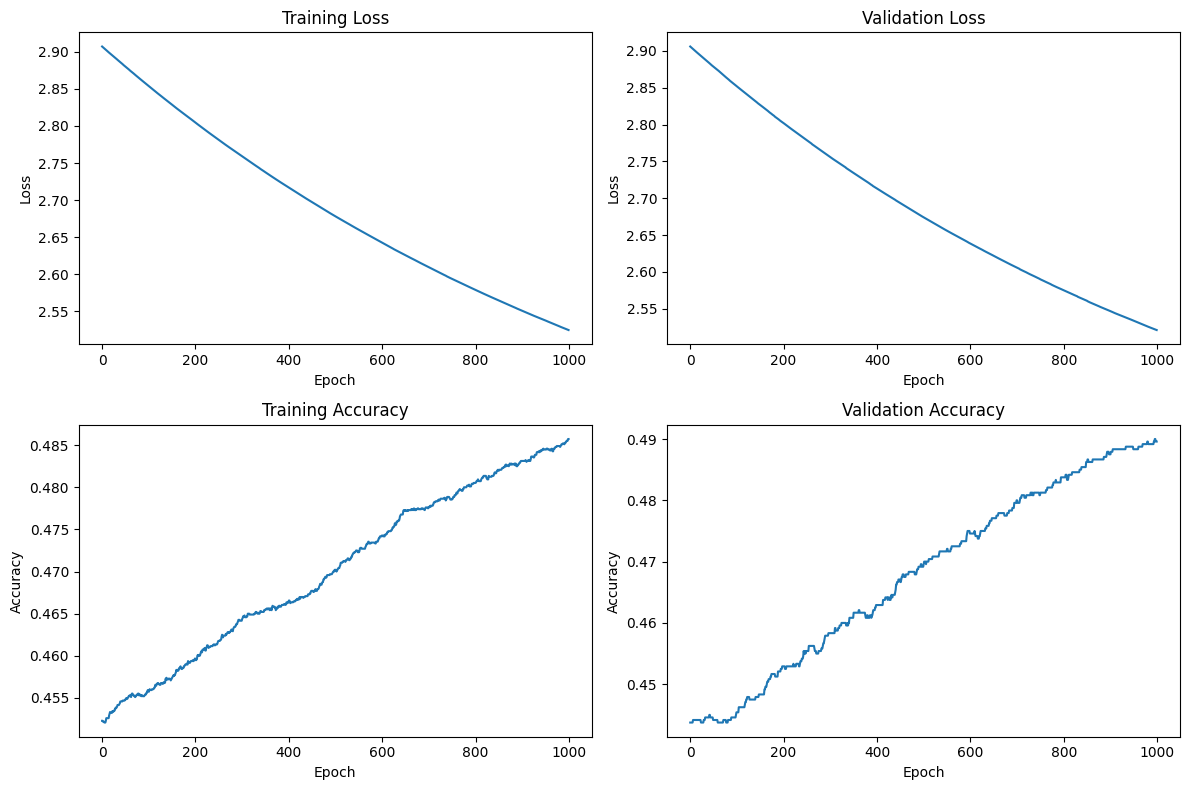

In [29]:
epochs_list = list(range(epochs))
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs_list, train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(2, 2, 2)
plt.plot(epochs_list, val_losses, label='Val Loss')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(2, 2, 3)
plt.plot(epochs_list, train_accs, label='Train Acc')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(2, 2, 4)
plt.plot(epochs_list, val_accs, label='Val Acc')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


## Required Explanation (Markdown)

Explain:

* why logistic regression is suitable for binary classification,
* why sigmoid is used,
* why the derivative simplifies to $$\frac{\partial L}{\partial z} = \hat{y} - y$$,
* why we can implement gradient descent here without autograd.

* Logistic regression has only 2 outputs so it works for binary classification
* Sigmoid is used because it returns values from 0 to 1. These are our probabilities.
* ![Derivative](./image.png)
* We can implement GD here because we calculated gradient function ourselves

# Task 2 — Logistic Regression: Manual Gradients vs Autograd (2 pts)

In this task you will verify your manual gradient calculations.

## Requirements

Using the **same dataset** and **same model**, compare:

* manual gradient computation,
* autograd gradient computation.

### Steps


1. Pick one mini-batch or a small subset of training data.
2. Compute:
   * manual $\frac{\partial L}{\partial W}$ and $\frac{\partial L}{\partial b}$,
   * autograd versions using `requires_grad=True` and `loss.backward()`.
3. Compare the values numerically.

You may report:

$$
\left\| \nabla_W^{\text{manual}} - \nabla_W^{\text{autograd}} \right\|
$$

and similarly for $b$.

In [37]:
W = torch.ones((784, 1), requires_grad=False)
b = torch.ones(1, requires_grad=False)

W_auto = torch.ones((784, 1), requires_grad=True)
b_auto = torch.ones(1, requires_grad=True)

In [38]:
z = X_train_norm @ W + b
preds = torch.clamp(1 / (1 + torch.exp(-1 * z)), 1e-7, 1-1e-7)
BCE_loss = -1 * torch.mean(y_train * torch.log(preds) + (1 - y_train) * torch.log(1 - preds))

grad_W_man = X_train_norm.T @ (preds - y_train) / X_train_norm.shape[0]
grad_b_man = (preds - y_train).mean()

In [39]:
z = X_train_norm @ W_auto + b_auto
preds = torch.clamp(1 / (1 + torch.exp(-1 * z)), 1e-7, 1-1e-7)
BCE_loss = -1 * torch.mean(y_train * torch.log(preds) + (1 - y_train) * torch.log(1 - preds))

BCE_loss.backward()
grad_W_auto = W_auto.grad
grad_b_auto = b_auto.grad

In [40]:
diff_W = torch.norm(grad_W_man - grad_W_auto)
diff_b = torch.norm(grad_b_man - grad_b_auto)

print("||grad_W_man - grad_W_auto|| =", diff_W.item())
print("||grad_b_man - grad_b_auto|| =", diff_b.item())

||grad_W_man - grad_W_auto|| = 4.625547409057617
||grad_b_man - grad_b_auto|| = 0.44885411858558655


## Required Explanation (Markdown)

Discuss:

* why the two gradients should match,
* possible reasons for small numerical differences,
* why checking gradients is useful when implementing models from scratch.


* Both calculate the same thing
* floating point precission, operation order
* We verify that manual gradient formulas are correct.

# Task 3 — MLP with 1 Hidden Layer (3 pts)

Now move from logistic regression to a neural network with one hidden layer.

Use the model

$$
a^{(0)} = x
$$

$$
z^{(1)} = a^{(0)} (W^{(1)})^T + b^{(1)}
$$

$$
a^{(1)} = g(z^{(1)})
$$

$$
z^{(2)} = a^{(1)} (W^{(2)})^T + b^{(2)}
$$

$$
\hat{y} = \sigma(z^{(2)})
$$

Choose a hidden activation such as $\tanh$ (see @[https://en.wikipedia.org/wiki/Hyperbolic_functions](mention://18b8a955-f332-42d0-8488-eb90b2ab27c6/url/4bf2f413-aea3-4855-8082-c1d3ade4b321) )

## Requirements


1. Implement all parameters manually as tensors:
   * $$
     W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}
     $$
2. Implement the forward pass manually.
3. Use manual binary cross-entropy.
4. Use autograd for gradients:
   * call `loss.backward()`,
   * update parameters manually inside `torch.no_grad()`.
5. Train for at least **100 epochs**.
6. Report training and validation:
   * loss,
   * accuracy.

## Plots

Plot:

* training loss vs epoch,
* validation loss vs epoch,
* training accuracy vs epoch,
* validation accuracy vs epoch.

In [56]:
W_1 = torch.randn((784, 64), requires_grad=True)
W_2 = torch.randn((64, 1), requires_grad=True)
b_1 = torch.randn(64, requires_grad=True)
b_2 = torch.randn(1, requires_grad=True)

In [57]:
epochs = 1000
lr = 1e-4

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    z_1 = X_train_norm @ W_1 + b_1
    a_1 = torch.tanh(z_1)
    z_2 = a_1 @ W_2 + b_2
    a_2 = torch.tanh(z_2)
    preds = torch.clamp(1 / (1 + torch.exp(-1 * a_2)), 1e-7, 1-1e-7)
    BCE_loss = -1 * torch.mean(y_train * torch.log(preds) + (1 - y_train) * torch.log(1 - preds))

    BCE_loss.backward()


    with torch.no_grad():
        W_1 -= lr * W_1.grad
        W_2 -= lr * W_2.grad
        b_1 -= lr * b_1.grad
        b_2 -= lr * b_2.grad

        W_1.grad.zero_()
        b_1.grad.zero_()
        W_2.grad.zero_()
        b_2.grad.zero_()

        train_losses.append(BCE_loss.item())

        z_1 = X_val_norm @ W_1 + b_1
        a_1 = torch.tanh(z_1)
        z_2 = a_1 @ W_2 + b_2
        a_2 = torch.tanh(z_2)
        val_preds = torch.clamp(1 / (1 + torch.exp(-1 * a_2)), 1e-7, 1-1e-7)
        val_loss = -1 * torch.mean(y_val * torch.log(val_preds) + (1 - y_val) * torch.log(1 - val_preds))
        val_losses.append(val_loss.item())

    train_acc = ((preds > 0.5).float() == y_train).float().mean()
    val_acc = ((val_preds > 0.5).float() == y_val).float().mean()
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

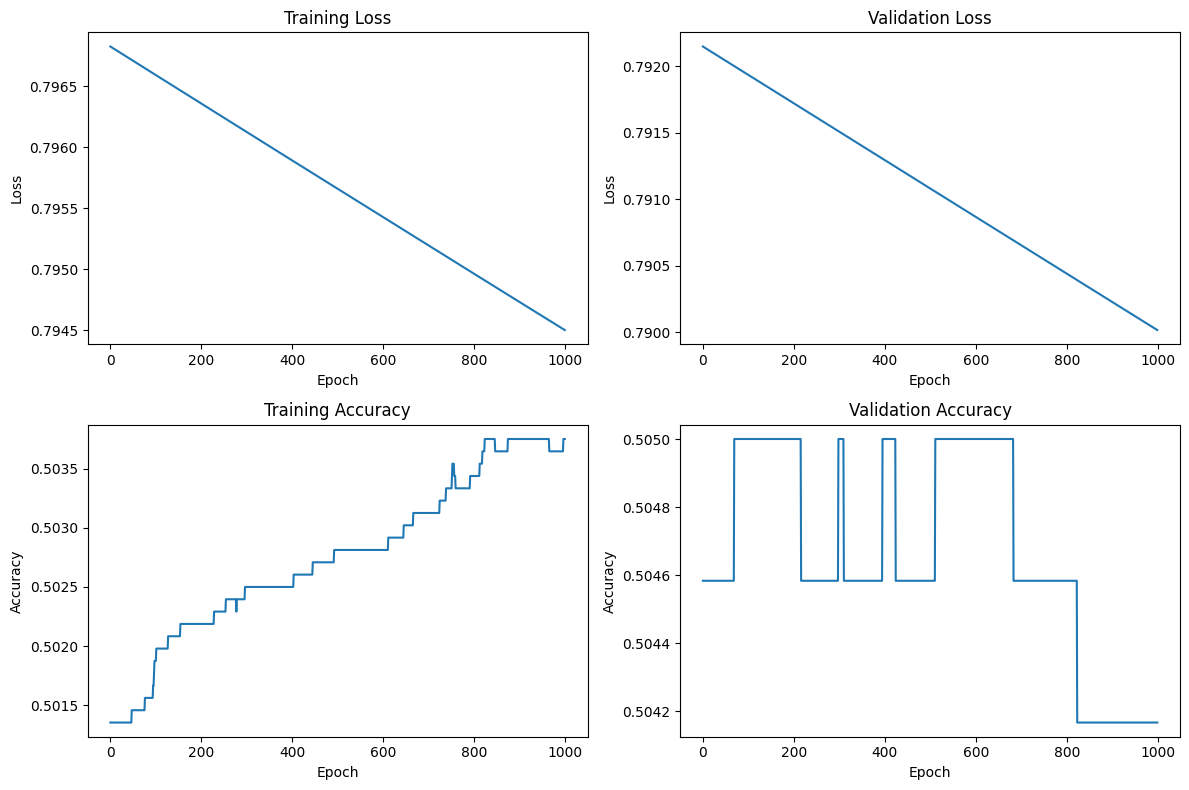

In [58]:
epochs_list = list(range(epochs))
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs_list, train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(2, 2, 2)
plt.plot(epochs_list, val_losses, label='Val Loss')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(2, 2, 3)
plt.plot(epochs_list, train_accs, label='Train Acc')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(2, 2, 4)
plt.plot(epochs_list, val_accs, label='Val Acc')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


## Required Explanation (Markdown)

Explain:

* why an MLP can model more complex decision boundaries than logistic regression,
* the role of the hidden activation function,
* why we still need a sigmoid in the output layer

* Because it is nonlinear. Nonlinear -> more complex decision boundaries.
* Hidden activation function makes calculations nonlinear.
* We want probabilities so we need sigmoid.

# Task 4 — MLP with 2+ Hidden Layers (2 pts)


Extend the previous model to **two (or more) hidden layers**.

Example architecture:

$$
a^{(0)} = x
$$

$$
z^{(1)} = a^{(0)} (W^{(1)})^T + b^{(1)}, \qquad a^{(1)} = g(z^{(1)})
$$

$$
z^{(2)} = a^{(1)} (W^{(2)})^T + b^{(2)}, \qquad a^{(2)} = g(z^{(2)})
$$

$$
z^{(3)} = a^{(2)} (W^{(3)})^T + b^{(3)}, \qquad \hat{y} = \sigma(z^{(3)})
$$

## Requirements


1. Implement a 2-hidden-layer MLP manually.
2. Train it on the same binary dataset.
3. Compare its performance with:
   * logistic regression,
   * 1-hidden-layer MLP.

## Required Comparison

Report for all three models:

* final train loss,
* final validation loss,
* final train accuracy,
* final validation accuracy.

In [71]:
W_1 = torch.randn((784, 128), requires_grad=True)
W_2 = torch.randn((128, 32), requires_grad=True)
W_3 = torch.randn((32, 1), requires_grad=True)
b_1 = torch.randn(128, requires_grad=True)
b_2 = torch.randn(32, requires_grad=True)
b_3 = torch.randn(1, requires_grad=True)

In [72]:
epochs = 1000
lr = 1e-4

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    z_1 = X_train_norm @ W_1 + b_1
    a_1 = torch.tanh(z_1)
    z_2 = a_1 @ W_2 + b_2
    a_2 = torch.tanh(z_2)
    z_3 = a_2 @ W_3 + b_3
    a_3 = torch.tanh(z_3)
    preds = torch.clamp(1 / (1 + torch.exp(-1 * a_3)), 1e-7, 1-1e-7)
    BCE_loss = -1 * torch.mean(y_train * torch.log(preds) + (1 - y_train) * torch.log(1 - preds))

    BCE_loss.backward()


    with torch.no_grad():
        W_1 -= lr * W_1.grad
        W_2 -= lr * W_2.grad
        W_3 -= lr * W_3.grad
        b_1 -= lr * b_1.grad
        b_2 -= lr * b_2.grad
        b_3 -= lr * b_3.grad

        W_1.grad.zero_()
        b_1.grad.zero_()
        W_2.grad.zero_()
        b_2.grad.zero_()
        W_3.grad.zero_()
        b_3.grad.zero_()

        train_losses.append(BCE_loss.item())

        z_1 = X_val_norm @ W_1 + b_1
        a_1 = torch.tanh(z_1)
        z_2 = a_1 @ W_2 + b_2
        a_2 = torch.tanh(z_2)
        z_3 = a_2 @ W_3 + b_3
        a_3 = torch.tanh(z_2)
        val_preds = torch.clamp(1 / (1 + torch.exp(-1 * a_3)), 1e-7, 1-1e-7)
        BCE_loss = -1 * torch.mean(y_val * torch.log(val_preds) + (1 - y_val) * torch.log(1 - val_preds))
        val_losses.append(BCE_loss.item())

    train_acc = ((preds > 0.5).float() == y_train).float().mean()
    val_acc = ((val_preds > 0.5).float() == y_val).float().mean()
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

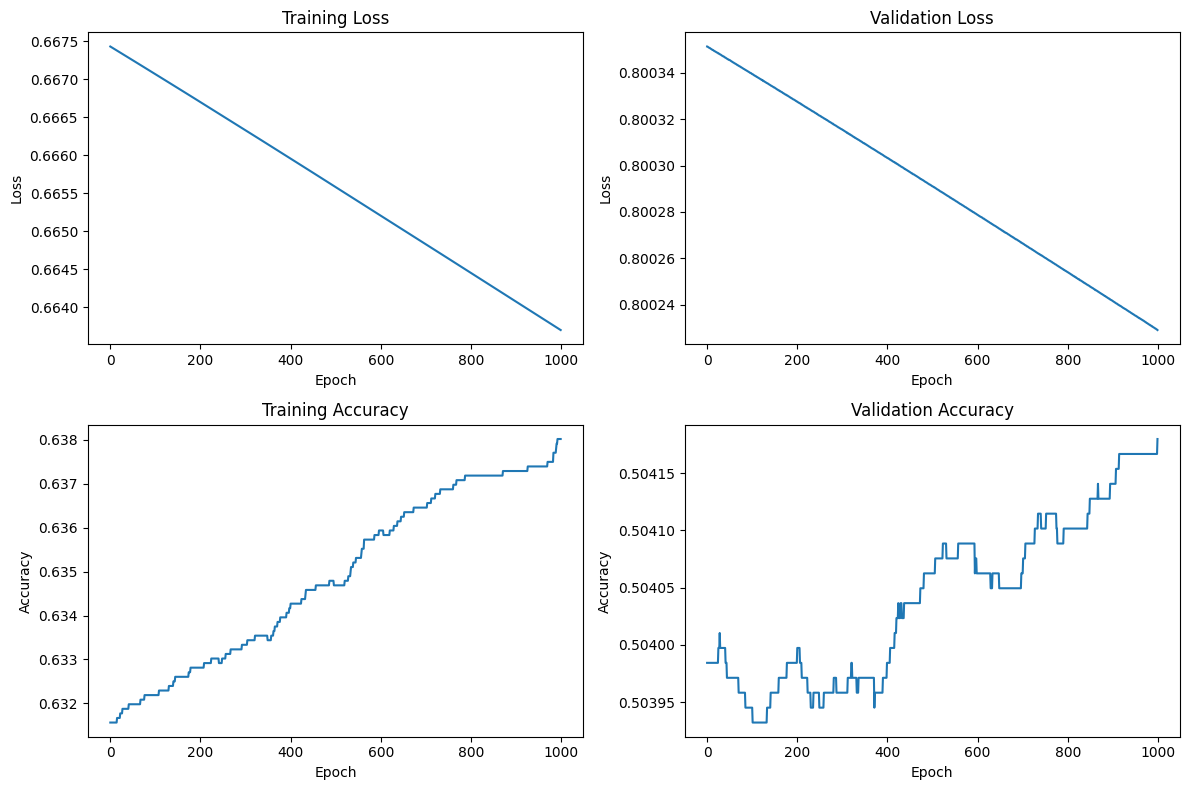

In [73]:
epochs_list = list(range(epochs))
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(epochs_list, train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(2, 2, 2)
plt.plot(epochs_list, val_losses, label='Val Loss')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(2, 2, 3)
plt.plot(epochs_list, train_accs, label='Train Acc')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(2, 2, 4)
plt.plot(epochs_list, val_accs, label='Val Acc')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


## Required Explanation (Markdown)

Discuss:

* whether deeper models improved performance,
* whether the extra hidden layer was helpful,
* why a deeper model may help or may fail to help on this binary task.

* Deeper model marginally had helped the results. In training it performs much better but in validation not so much.
* Not really.
* It can create better features with weights and use those features to classify better.